In [1]:
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
np.float_ = np.float64
import scanpy as sc
import seaborn as sns
import scipy
data_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/Lawson_map_combined/all-sample/DGE_filtered/'
fig_path = '/Volumes/CSDG/Daniel_Gray/Daniel_scRNA_seq/analysis_figures/'

In [2]:
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

In [3]:
import warnings
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

## Loading in

In [4]:
adata = sc.read(data_path + 'labelled.h5ad')

In [5]:
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,ref5_label,ref5_score,ref10_label,ref10_score,predicted,transfer_score,overcluster,ref_label,CellType,CellTypeMajor
13_01_82__s1,R21-2,Law-GRC11,652,1061,1928,13,1,82,B1,A1,...,central nervous system,0.855223,cone retinal bipolar cell,1.000000,cone retinal bipolar cell,1.000000,41,central nervous system,Ret-BP,Retinal
13_03_45__s1,R21-2,Law-GRC11,370,502,855,13,3,45,B1,A3,...,central nervous system,0.999572,cone retinal bipolar cell,1.000000,cone retinal bipolar cell,0.998236,50,central nervous system,Ret-BP,Retinal
13_03_65__s1,R21-2,Law-GRC11,849,1289,2282,13,3,65,B1,A3,...,neuron,0.999908,peripheral nervous system,0.999999,peripheral nervous system,0.995435,19,neuron,Neuron-Glut,Neural
13_03_73__s1,R21-2,Law-GRC11,1131,1865,3234,13,3,73,B1,A3,...,epidermal cell,1.000000,epidermal cell,0.999959,epidermal cell,0.638134,77,epidermal cell,Taste Bud,Ectodermal
13_04_26__s1,R21-2,Law-GRC11,616,1024,1841,13,4,26,B1,A4,...,epidermal cell,1.000000,epidermal cell,1.000000,epidermal cell,0.887605,13,periderm,Periderm,Ectodermal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48_94_76__s8,Wts-3,Law-GRC11,445,599,1086,48,94,76,D12,H10,...,enteric musculature,1.000000,dermis,0.999998,dermis,0.998054,37,enteric musculature,Cranial-Mes,Mesenchymal
48_95_46__s8,Wts-3,Law-GRC11,1153,2082,3863,48,95,46,D12,H11,...,neuron,1.000000,peripheral nervous system,1.000000,peripheral nervous system,0.999997,3,neuron,Neuron-Glyc,Neural
48_95_57__s8,Wts-3,Law-GRC11,1006,1672,3099,48,95,57,D12,H11,...,neuron,0.999988,peripheral nervous system,0.044739,peripheral nervous system,0.983963,63,neuron,Neuron,Neural
48_95_60__s8,Wts-3,Law-GRC11,622,928,1688,48,95,60,D12,H11,...,neuron,0.999998,cone retinal bipolar cell,0.999970,cone retinal bipolar cell,1.000000,45,neuron,Ret-BP,Retinal


In [22]:
genotypes = ["Wik","S2b"]
cell_subset = adata[adata.obs["genotype"].isin(genotypes)]
cell_subset.obs['CellTypeMajor']

01_02_36__s1        Retinal
01_02_87__s1         Neural
01_05_40__s1        Retinal
01_05_70__s1         Neural
01_06_71__s1     Ectodermal
                   ...     
36_92_74__s8         Neural
36_93_02__s8            NaN
36_93_37__s8    Mesenchymal
36_93_82__s8         Neural
36_95_20__s8         Neural
Name: CellTypeMajor, Length: 28264, dtype: category
Categories (4, object): ['Ectodermal', 'Mesenchymal', 'Neural', 'Retinal']

In [23]:
print(cell_subset.obs['CellTypeMajor'].value_counts())

CellTypeMajor
Neural         11439
Retinal         7631
Mesenchymal     4359
Ectodermal      3106
Name: count, dtype: int64


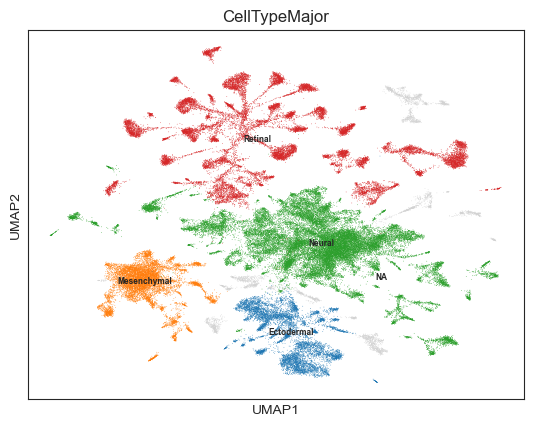

In [6]:
sc.pl.umap(adata, color = ['CellTypeMajor'], s = 1,legend_loc = 'on data',legend_fontsize=6, save = 'labelledmaj')

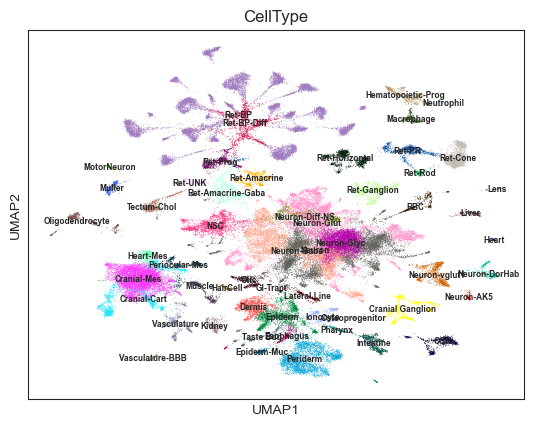

In [7]:
sc.pl.umap(adata, color = ['CellType'], s = 1,legend_loc = 'on data',legend_fontsize=6, save = 'labelled')

## Looking at raw cell type proportions

In [8]:
cov_geno = pd.DataFrame({"genotype": ["S2b", "Wik", "R21", "Wts", "S2b", "Wik", "R21", "Wts"]}, index=["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"])
cov_rep = pd.DataFrame({"replicate": ["2", "2", "2", "2", "3", "3", "3", "3"]}, index=["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"])
cov_sample = pd.DataFrame({"sample": ["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"]}, index=["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"])

### Major Clusters

In [9]:
geno_order = ["Wik", "S2b"]
adatas = adata[adata.obs['genotype'].isin(geno_order)]
majorneurons = ['Neuron','Neuron-Gaba','Neuron-Glut','Neuron-Glyc','Neuron-Diff-NS','NSC']
adatas
cov_geno = pd.DataFrame({"genotype": ["S2b", "Wik", "S2b", "Wik"]}, index=["S2b-2","Wik-2","S2b-3","Wik-3"])

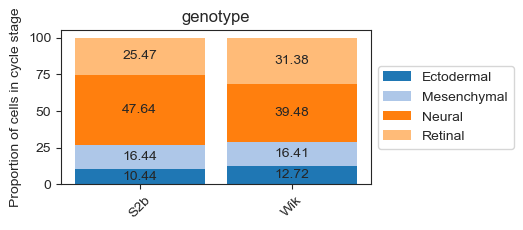

In [10]:
# ["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"]
data_scanpy = dat.from_scanpy(
    adatas,
    cell_type_identifier="CellTypeMajor",
    sample_identifier="sample",
    covariate_df=cov_geno)

ax = viz.stacked_barplot(
    data_scanpy,
    feature_name="genotype", 
    figsize=(4, 2)
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Proportion of cells in cycle stage")
for c in ax.containers:
    # Optional: if the segment is small or 0, customize the labels
    labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
    # remove the labels parameter if it's not needed for customized labels
    ax.bar_label(c, fmt='%.2f', label_type='center')
    
# level_order=["S2b-2","Wik-2","S2b-3","Wik-3"]

plt.savefig(fig_path+"celltypesmajor_props.pdf", dpi=300)

In [11]:
data_scanpy = dat.from_scanpy(
    adatas,
    cell_type_identifier="CellType",
    sample_identifier="sample",
    covariate_df=cov_geno)
data_scanpy
data_scanpy1=data_scanpy[:, (majorneurons)]

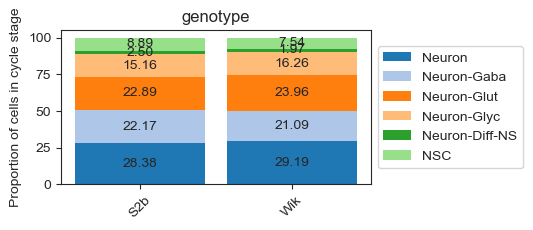

In [12]:
# ["S2b-2","Wik-2","R21-2","Wts-2","S2b-3","Wik-3","R21-3","Wts-3"]
ax = viz.stacked_barplot(
    data_scanpy1,
    feature_name="genotype", 
    figsize=(4, 2)
)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Proportion of cells in cycle stage")
for c in ax.containers:
    # Optional: if the segment is small or 0, customize the labels
    labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
    # remove the labels parameter if it's not needed for customized labels
    ax.bar_label(c, fmt='%.2f', label_type='center')
    
# level_order=["S2b-2","Wik-2","S2b-3","Wik-3"]

plt.savefig(fig_path+"celltypesneural_props.pdf", dpi=300)

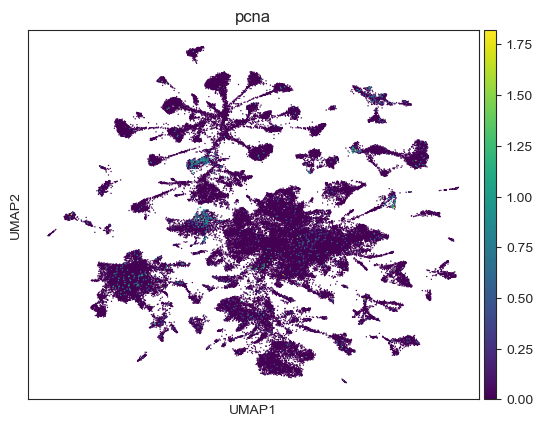

In [13]:
gene_list = ['pcna']
sc.pl.umap(adata, color=[i for i in gene_list], color_map='viridis', legend_fontsize=8, legend_loc = 'on data', s=4, save = 'pcnadistribution')

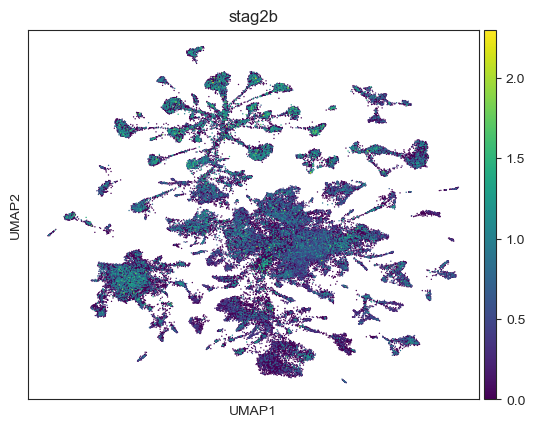

In [14]:
gene_list = ['stag2b']
sc.pl.umap(adata, color=[i for i in gene_list], color_map='viridis', legend_fontsize=8, legend_loc = 'on data', s=4, save = 'stag2bdistribution')

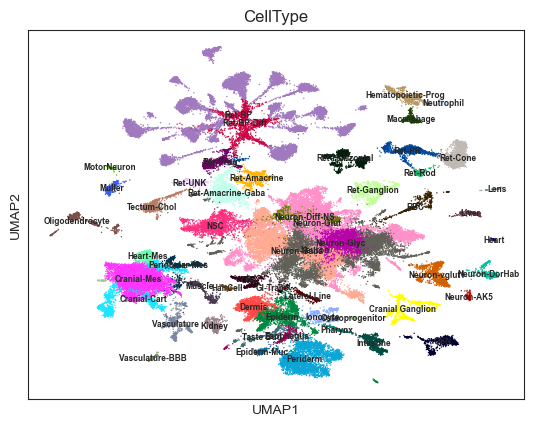

In [15]:
sc.pl.umap(adata, color = ['CellType'], legend_loc = 'on data',legend_fontsize=6, s=4, save = 'labelledminor')